# 04 Mô hình hóa - Dự đoán năng suất cây trồng

Notebook này xây dựng các mô hình học máy để dự đoán năng suất cây trồng dựa trên các yếu tố môi trường.

Các mô hình được sử dụng:

- Hồi quy tuyến tính (Cơ sở)

- Mô hình hồi quy rừng ngẫu nhiên

- Mô hình hồi quy XGBoost

Các chỉ số đánh giá:

- MAE
- RMSE

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor

In [2]:
df = pd.read_csv(
r"D:\HocTap\DATA_MINING\DATA_MINING_PROJECT\data\processed\crop_processed.csv"
)

df.head()

,Unnamed: 0,Area,Item,Year,yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,0,1,1990,36613,0.473294,-0.616366,-0.661069
1,1,0,3,1990,66667,0.473294,-0.616366,-0.661069
2,2,0,4,1990,23333,0.473294,-0.616366,-0.661069
3,3,0,5,1990,12500,0.473294,-0.616366,-0.661069
4,4,0,6,1990,7000,0.473294,-0.616366,-0.661069


In [3]:
df = df.rename(columns={"hg/ha_yield":"yield"})

# Cell 2: Chọn Feature và Target

Feature:

rainfall

pesticides

temperature

year

area

item

In [4]:
X = df[
[
"Area",
"Item",
"Year",
"average_rain_fall_mm_per_year",
"pesticides_tonnes",
"avg_temp"
]
]

y = df["yield"]

# Cell 3 :Time Split (theo năm)

Đề bài yêu cầu split theo thời gian.

Ví dụ:

train: trước 2013

test: từ 2013 trở đi

In [5]:
train = df[df["Year"] < 2013]

test = df[df["Year"] >= 2013]

X_train = train[X.columns]
y_train = train["yield"]

X_test = test[X.columns]
y_test = test["yield"]

Kiểm tra:

In [6]:
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (26983, 6)
Test size: (1259, 6)


# Cell 4: Baseline Model — Linear Regression

In [7]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

Hiển thị bảng để xem model dự đoán có gần với thực tế không.

In [8]:
result_lr = pd.DataFrame({
"Actual Yield": y_test,
"Predicted Yield": y_pred_lr
})

result_lr.head(10)

,Actual Yield,Predicted Yield
95,69533,113008.014373
96,260110,97805.379159
97,10000,75001.426338
98,41292,59798.791124
208,33649,110106.354305
209,303218,94903.719091
210,17778,87302.401484
211,60000,79701.083877
212,19100,56897.131056
369,140517,105358.370361


# Cell 5 : Evaluation


In [9]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression MAE:", mae_lr)

print("Linear Regression RMSE:", rmse_lr)

Linear Regression MAE: 72558.35317874073
Linear Regression RMSE: 93281.7640233567


# Cell 7 : Random Forest
Biểu đồ Actual vs Predicted

Biểu đồ rất quan trọng trong regression.


In [11]:
rf = RandomForestRegressor(
n_estimators=200,
random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

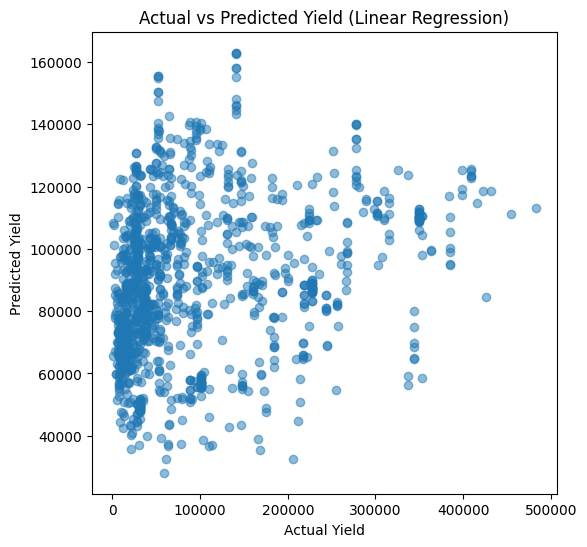

In [12]:
plt.figure(figsize=(6,6))

plt.scatter(
y_test,
y_pred_lr,
alpha=0.5
)

plt.xlabel("Actual Yield")

plt.ylabel("Predicted Yield")

plt.title("Actual vs Predicted Yield (Linear Regression)")

plt.show()

# Cell 8 : Evaluation

In [13]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest MAE:", mae_rf)

print("Random Forest RMSE:", rmse_rf)

Random Forest MAE: 8906.468355837967
Random Forest RMSE: 18149.461681906654


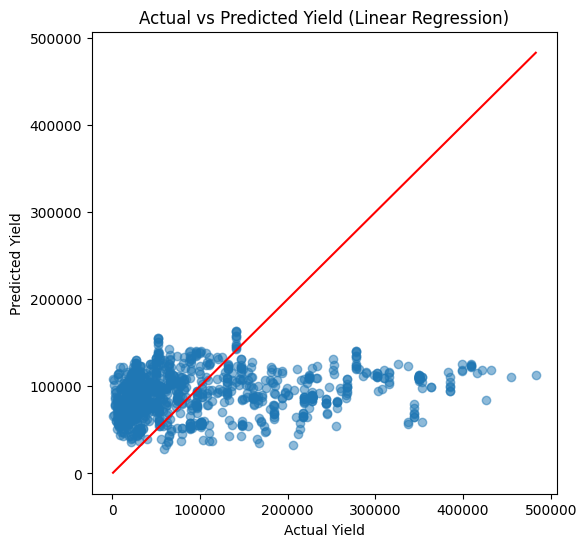

In [14]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_lr, alpha=0.5)

plt.plot(
[y_test.min(), y_test.max()],
[y_test.min(), y_test.max()],
color="red"
)

plt.xlabel("Actual Yield")

plt.ylabel("Predicted Yield")

plt.title("Actual vs Predicted Yield (Linear Regression)")

plt.show()

# Cell 9 : XGBoost (Model mạnh)

In [15]:
xgb = XGBRegressor(
n_estimators=300,
learning_rate=0.05,
max_depth=6,
random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [16]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost MAE:", mae_xgb)

print("XGBoost RMSE:", rmse_xgb)

XGBoost MAE: 12210.1845703125
XGBoost RMSE: 21249.000729446077


In [23]:
pred_df = pd.DataFrame({
"Actual": y_test,
"Predicted": y_pred_xgb
})

pred_df.to_csv(
r"D:\HocTap\DATA_MINING\DATA_MINING_PROJECT\data\processed\prediction_xgb.csv",
index=False
)

pred_df.head()

,Actual,Predicted
95,69533,60235.613281
96,260110,190652.984375
97,10000,20941.255859
98,41292,32080.503906
208,33649,45178.742188


# Cell 10 : So sánh các mô hình


In [17]:
results = pd.DataFrame({

"Model":[
"Linear Regression",
"Random Forest",
"XGBoost"
],

"MAE":[
mae_lr,
mae_rf,
mae_xgb
],

"RMSE":[
rmse_lr,
rmse_rf,
rmse_xgb
]

})

results

,Model,MAE,RMSE
0,Linear Regression,72558.353179,93281.764023
1,Random Forest,8906.468356,18149.461682
2,XGBoost,12210.184570,21249.000729


Visualization so sánh model

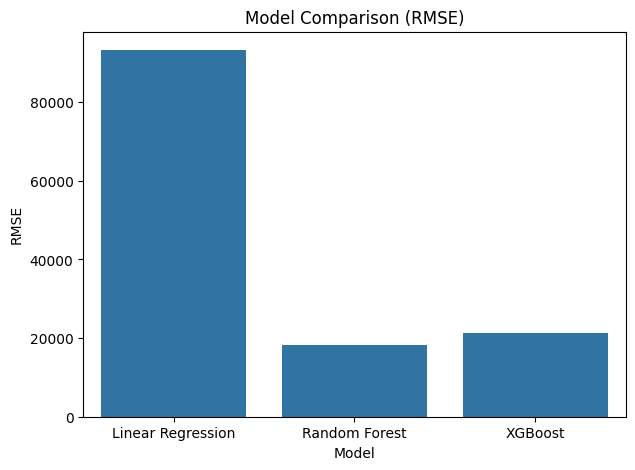

In [18]:
plt.figure(figsize=(7,5))

sns.barplot(
x="Model",
y="RMSE",
data=results
)

plt.title("Model Comparison (RMSE)")

plt.show()

Biểu đồ dự đoán vs thực tế

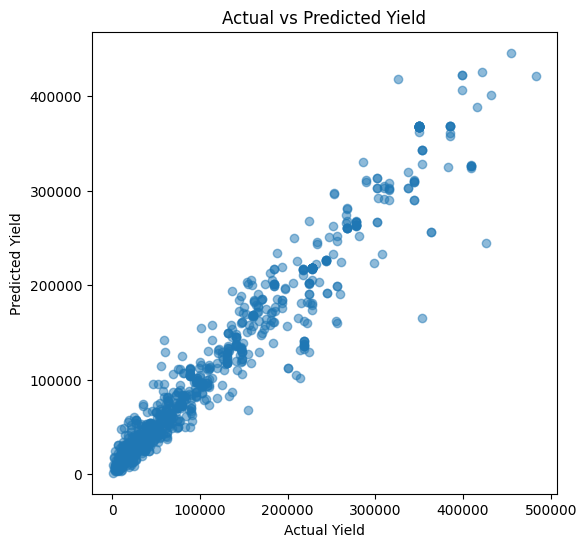

In [19]:
plt.figure(figsize=(6,6))

plt.scatter(
y_test,
y_pred_xgb,
alpha=0.5
)

plt.xlabel("Actual Yield")

plt.ylabel("Predicted Yield")

plt.title("Actual vs Predicted Yield")

plt.show()

Feature Importance

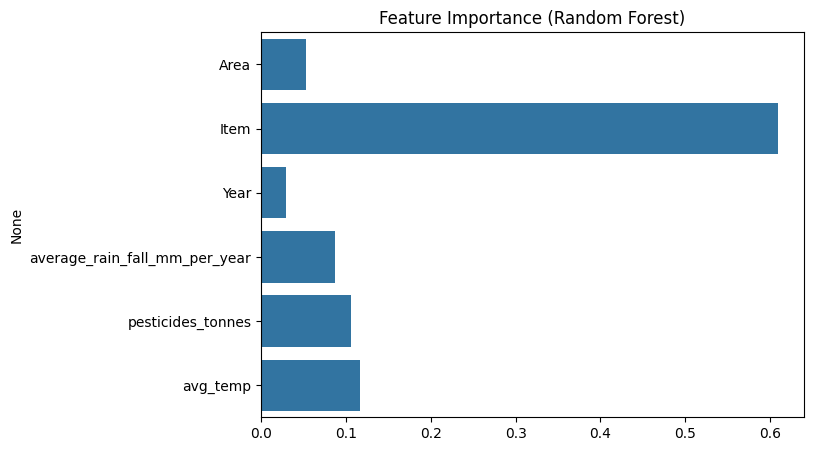

In [20]:
importances = rf.feature_importances_

features = X.columns

plt.figure(figsize=(7,5))

sns.barplot(
x=importances,
y=features
)

plt.title("Feature Importance (Random Forest)")

plt.show()

In [22]:
results = pd.DataFrame({
"Model":["Linear Regression","Random Forest","XGBoost"],
"MAE":[mae_lr, mae_rf, mae_xgb],
"RMSE":[rmse_lr, rmse_rf, rmse_xgb]
})

results.to_csv(
r"D:\HocTap\DATA_MINING\DATA_MINING_PROJECT\data\processed\model_results.csv",
index=False
)

results

,Model,MAE,RMSE
0,Linear Regression,72558.353179,93281.764023
1,Random Forest,8906.468356,18149.461682
2,XGBoost,12210.184570,21249.000729


### Hiệu suất mô hình

Ba mô hình đã được huấn luyện để dự đoán năng suất cây trồng:

- Hồi quy tuyến tính (mô hình cơ sở)

- Rừng ngẫu nhiên

- XGBoost

Kết quả cho thấy các mô hình dựa trên cây quyết định hiệu quả hơn mô hình tuyến tính cơ sở.

Rừng ngẫu nhiên và XGBoost nắm bắt các mối quan hệ phi tuyến tính giữa các yếu tố môi trường và năng suất cây trồng hiệu quả hơn.